# Arena Sagaz — Treinamento CNN V3 (Auto-Play Dataset)

Versão V3 do notebook de treino, compatível com datasets gerados pelo
`Otimizacao_Topologia_Rede_V3.ipynb` (auto-play Minimax).

**Mudanças em relação ao notebook anterior:**
- Leitura do campo `generation_mode` (0=random, 1=p1, 2=p2, 3=p3)
- Suporte opcional a `sample_weight` ponderado por `generation_mode`
- Métricas (Top-1/Top-3/Top-5/OMA) **por generation_mode** na avaliação
- Histograma de distribuição das amostras por modo
- Compatível com datasets V2 sem `generation_mode` (fallback mode=0)


In [1]:
import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Reduz logs internos do TensorFlow para deixar a saída do notebook mais limpa.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
sns.set_theme(style="whitegrid")

# Sementes fixas para reprodutibilidade dos experimentos.
np.random.seed(42)
tf.keras.utils.set_random_seed(42)

print("TensorFlow:", tf.__version__)
print("GPU disponível:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow: 2.19.0
GPU disponível: True


## 1. Carregamento, Normalização e Split

Lê arquivos `.npz` do V3 (com `generation_mode`) ou V2 (sem — fallback para 0).
Normalização: `8 → 0` (pontos fixos), `9 → 1` (arestas).


In [9]:
# =========================================================================
# 1.1 LEITURA DOS LOTES
# =========================================================================
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

MODE_NAMES = {0: 'random(p=0)', 1: 'autoplay(p=1)', 2: 'autoplay(p=2)', 3: 'autoplay(p=3)'}

# Configuracao de pesos por generation_mode (sample_weight).
# Defina USE_SAMPLE_WEIGHT = False para treinar sem pesos (recomendado como baseline).
USE_SAMPLE_WEIGHT = False
MODE_WEIGHTS = {0: 1.0, 1: 2.0, 2: 3.0, 3: 3.0}  # ajuste conforme resultados

arquivos_npz = sorted(glob.glob('../dados_v3/*.npz'))
if not arquivos_npz:
    arquivos_npz = sorted(glob.glob('*.npz'))
print(f'Encontrados {len(arquivos_npz)} arquivos.')

lista_estados, lista_rotulos, lista_scores, lista_gen_modes = [], [], [], []
labels_canonicos = None

for arquivo in arquivos_npz:
    dados = np.load(arquivo, allow_pickle=True)
    lista_estados.append(dados['estados'])
    lista_rotulos.append(dados['rotulos'])
    lista_scores.append(dados['scores'])
    # Compatibilidade com datasets V2 (sem generation_mode)
    if 'generation_mode' in dados:
        lista_gen_modes.append(dados['generation_mode'])
    else:
        lista_gen_modes.append(np.zeros(len(dados['estados']), dtype=np.int8))
    if labels_canonicos is None:
        labels_canonicos = dados['labels_canonicos'].tolist()

X_raw        = np.concatenate(lista_estados,   axis=0).astype(np.float32)
y_str        = np.concatenate(lista_rotulos,   axis=0)
scores_raw   = np.concatenate(lista_scores,    axis=0)
gen_modes    = np.concatenate(lista_gen_modes, axis=0).astype(np.int8)

print(f'Total de amostras: {len(X_raw):,}')
print(f'Shape entrada: {X_raw.shape} | Scores: {scores_raw.shape}')

# Distribuicao por generation_mode
print('\nDistribuicao por generation_mode:')
for m in sorted(set(gen_modes.tolist())):
    n = (gen_modes == m).sum()
    print(f'  {MODE_NAMES.get(m, str(m))}: {n:,} ({n/len(gen_modes)*100:.1f}%)')

# =========================================================================
# 1.2 NORMALIZACAO
# =========================================================================
X_raw[X_raw == 8] = 0.0   # pontos fixos -> 0
X_raw[X_raw == 9] = 1.0   # arestas -> 1 (V3 e V2 normalizados)

# =========================================================================
# 1.3 SOFT TARGETS (KL Divergence)
# =========================================================================
SCORE_IND = -1e9
label_to_idx = {l: i for i, l in enumerate(labels_canonicos)}
num_classes = len(labels_canonicos)
indice_para_rotulo = {i: l for i, l in enumerate(labels_canonicos)}
T = 1.0  # temperatura
y_soft = np.zeros((len(scores_raw), num_classes), dtype=np.float32)

for i, sv in enumerate(scores_raw):
    mask = sv > SCORE_IND
    if mask.sum() == 0:
        y_soft[i] = 1.0 / num_classes
        continue
    vals = sv[mask] / T
    vals -= vals.max()
    exp_v = np.exp(vals)
    y_soft[i, mask] = exp_v / exp_v.sum()

y_idx = y_soft.argmax(axis=1)

# Tensor de entrada: adiciona dim de canal
X = X_raw[..., np.newaxis]

# =========================================================================
# 1.4 SPLIT 70/15/15
# =========================================================================
idx_all = np.arange(len(X))
idx_tv, idx_test = train_test_split(idx_all, test_size=0.15, random_state=42)
idx_train, idx_val = train_test_split(idx_tv,  test_size=0.15/0.85, random_state=42)

X_train, y_train = X[idx_train], y_soft[idx_train]
X_val,   y_val   = X[idx_val],   y_soft[idx_val]
X_test,  y_test  = X[idx_test],  y_soft[idx_test]
y_test_idx       = y_idx[idx_test]
gen_test         = gen_modes[idx_test]
S_test           = scores_raw[idx_test]  # <--- Essa linha foi adicionada

# sample_weight (opcional)
if USE_SAMPLE_WEIGHT:
    sw = np.array([MODE_WEIGHTS.get(int(m), 1.0) for m in gen_modes[idx_train]], dtype=np.float32)
    print(f'sample_weight ativado: pesos {MODE_WEIGHTS}')
else:
    sw = None

print(f'\nTreino: {len(X_train):,}  |  Val: {len(X_val):,}  |  Teste: {len(X_test):,}')


Encontrados 60 arquivos.
Total de amostras: 357,000
Shape entrada: (357000, 9, 7) | Scores: (357000, 31)

Distribuicao por generation_mode:
  random(p=0): 53,324 (14.9%)
  autoplay(p=1): 88,946 (24.9%)
  autoplay(p=2): 197,052 (55.2%)
  autoplay(p=3): 17,678 (5.0%)

Treino: 249,900  |  Val: 53,550  |  Teste: 53,550


## 2. Arquitetura `BoxNet v3` — CNN Centrada em Caixas com Soft Targets

### Histórico de experimentos

| Rodada | Dataset | Prof. | Dados | top-1 | top-3 | top-5 | OMA | Loss | Observação principal |
|--------|---------|-------|-------|-------|-------|-------|-----|------|----------------------|
| CNN ingênua | Aleatorio | 3 | 50k | ~11% | — | — | — | CE | Abaixo do aleatório (1/31≈3.2%) — bug de mapeamento |
| MLP flat | Aleatorio | 5 | 50k | ~18% | — | — | — | CE | Sem captura de estrutura espacial |
| BoxNet v1 | Aleatorio | 5 | 50k | ~28% | ~58% | ~74% | — | CE | Plateau prematuro; argmax ambíguo |
| BoxNet v2 (argmax) | Aleatorio | 5 | 210k | ~36% | ~70% | ~83% | — | CE | Gap treino/val ≈9.6pp — soft targets necessários |
| BoxNet v3 R1 (KLD) | Q-values | 5 | 210k | ~35% | ~69% | ~82% | 99% | KLD | OMA=99%: top-1 mede desempate, não qualidade |
| BoxNet v3 R2 (T=0.5) | Q-values | 5 | 210k | ~33% | ~67% | ~80% | 99% | KLD | T=0.5 não ajuda (empates uniformes independem de T) |
| BoxNet v3 R3 (sw) | Q-values | 5 | 300k | ~31% | ~64% | ~79% | ~99% | KLD | sample_weight por freq. de classe causou regressão |
| BoxNet v3 R4 (T=1.0) | Q-values | 6 | 300k | ~35% | ~68% | ~81% | ~99% | KLD | Referência: win-rate vs MM(p=1)=96%, MM(p=3)=52% |
| BoxNet v3 R5 | Q-values | 7 | 300k | ~34% | ~68% | ~82% | ~99% | KLD | depth-7 **piorou** vs MM(p=1)=89%, MM(p=3)=45% |
| **BoxNet V3-AutoPlay** | **Auto-play** | **7** | **300k** | **?** | **?** | **?** | **?** | KLD | **Esta rodada** — dataset auto-play, estimativa: MM(p=3)~75-85% |

> **Por que top-1 ≈ 34% é aceitável**: com 31 traços possíveis, estados de abertura têm múltiplas
> jogadas Minimax-equivalentes. A CNN pode escolher qualquer uma delas (OMA=99%) mas o rótulo
> canônico registra apenas uma — deprimindo o top-1 artificialmente.
>
> **Por que depth-7 aleatório piorou vs depth-6**: o professor mais preciso aprendeu nuances de
> posições irreais (geradas por shuffle aleatório). O dataset auto-play resolve essa causa raiz.
> Ver `docs/historico_decisoes.md` para análise completa.


In [5]:
# =========================================================================
# CAMADA 0 — TRANSFORMAÇÃO GEOMÉTRICA (9,7,1) → (4,3,5)
# Reorganiza a matriz crua em grid centrado em CAIXAS.
# Convenção canônica (vide gerador_dados/tabuleiro.py):
#   linha PAR  + coluna ÍMPAR → traço Horizontal
#   linha ÍMPAR + coluna PAR  → traço Vertical
#   linha ÍMPAR + coluna ÍMPAR → interior da caixa
# =========================================================================
def para_grid_de_caixas(x):
    x = tf.squeeze(x, axis=-1)                # (B, 9, 7)
    topo     = x[:, 0:8:2, 1:7:2]             # (B,4,3) traço H acima
    base     = x[:, 2:9:2, 1:7:2]             # (B,4,3) traço H abaixo
    esquerda = x[:, 1:8:2, 0:6:2]             # (B,4,3) traço V à esquerda
    direita  = x[:, 1:8:2, 2:7:2]             # (B,4,3) traço V à direita
    interior = x[:, 1:8:2, 1:7:2]             # (B,4,3) dono da caixa
    return tf.stack([topo, base, esquerda, direita, interior], axis=-1)  # (B,4,3,5)


def bloco_residual_separavel(x, filtros, l2=2e-4, dropout=0.15):
    """Bloco residual: 2× SeparableConv2D 3×3 + BN + skip connection."""
    atalho = x
    y = layers.SeparableConv2D(
        filtros, (3, 3), padding='same', use_bias=False,
        depthwise_regularizer=regularizers.l2(l2),
        pointwise_regularizer=regularizers.l2(l2),
    )(x)
    y = layers.BatchNormalization()(y)
    y = layers.Activation('relu')(y)
    y = layers.SpatialDropout2D(dropout)(y)

    y = layers.SeparableConv2D(
        filtros, (3, 3), padding='same', use_bias=False,
        depthwise_regularizer=regularizers.l2(l2),
        pointwise_regularizer=regularizers.l2(l2),
    )(y)
    y = layers.BatchNormalization()(y)

    if atalho.shape[-1] != filtros:
        atalho = layers.Conv2D(filtros, (1, 1), padding='same', use_bias=False,
                               kernel_regularizer=regularizers.l2(l2))(atalho)
        atalho = layers.BatchNormalization()(atalho)

    out = layers.Add()([y, atalho])
    out = layers.Activation('relu')(out)
    return out


# =========================================================================
# ARQUITETURA BoxNet v3 — idêntica à v2, mas treinada com KL Divergence
# =========================================================================
L2 = 2e-4

inputs = Input(shape=(9, 7, 1), name='tabuleiro_cru')

x = layers.Lambda(para_grid_de_caixas, name='grid_de_caixas')(inputs)

x = layers.Conv2D(32, (3, 3), padding='same', use_bias=False,
                  kernel_regularizer=regularizers.l2(L2))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)

x = bloco_residual_separavel(x, 32, l2=L2, dropout=0.15)
x = bloco_residual_separavel(x, 48, l2=L2, dropout=0.20)

gap  = layers.GlobalAveragePooling2D()(x)
flat = layers.Flatten()(x)
h    = layers.Concatenate()([gap, flat])
h    = layers.Dense(96, activation='relu', kernel_regularizer=regularizers.l2(L2))(h)
h    = layers.BatchNormalization()(h)
h    = layers.Dropout(0.5)(h)

outputs = layers.Dense(num_classes, activation='softmax',
                       kernel_regularizer=regularizers.l2(L2),
                       name='jogada')(h)

model = models.Model(inputs, outputs, name='BoxNet_v3_ArenaSagaz')

# KLDivergence: mede distância entre a distribuição prevista e o soft target.
# Não usar label_smoothing — os soft targets já codificam suavização via Q-values.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.KLDivergence(),
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name='accuracy'),
        tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc'),
        tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_acc'),
    ],
)

model.summary()

Model: "BoxNet_v3_ArenaSagaz"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tabuleiro_cru       │ (None, 9, 7, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ grid_de_caixas      │ (None, 4, 3, 5)   │          0 │ tabuleiro_cru[0]… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 4, 3, 32)  │      1,440 │ grid_de_caixas[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 3, 32)  │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 4, 3, 32)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_4  │ (None, 4, 3, 32)  │      1,312 │ activation_5[0][… │
│ (SeparableConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 3, 32)  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 4, 3, 32)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_2 │ (None, 4, 3, 32)  │          0 │ activation_6[0][… │
│ (SpatialDropout2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_5  │ (None, 4, 3, 32)  │      1,312 │ spatial_dropout2… │
│ (SeparableConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 3, 32)  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 4, 3, 32)  │          0 │ batch_normalizat… │
│                     │                   │            │ activation_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 4, 3, 32)  │          0 │ add_2[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_6  │ (None, 4, 3, 48)  │      1,824 │ activation_7[0][… │
│ (SeparableConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 3, 48)  │        192 │ separable_conv2d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 4, 3, 48)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_3 │ (None, 4, 3, 48)  │          0 │ activation_8[0][… │
│ (SpatialDropout2D)  │                   │            │                 

 Total params: 74,511 (291.06 KB)

 Trainable params: 73,839 (288.43 KB)

 Non-trainable params: 672 (2.62 KB)

In [6]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5, verbose=1),
]

history = model.fit(
    X_train, y_train,
    epochs=120,
    batch_size=256,
    validation_data=(X_val, y_val),
    sample_weight=sw,   # None se USE_SAMPLE_WEIGHT=False
    callbacks=callbacks,
    verbose=2,
)


Epoch 1/120
977/977 - 33s - 34ms/step - accuracy: 0.2248 - loss: 1.0543 - top3_acc: 0.3927 - top5_acc: 0.4940 - val_accuracy: 0.3807 - val_loss: 0.4960 - val_top3_acc: 0.5841 - val_top5_acc: 0.6846 - learning_rate: 0.0010
Epoch 2/120
977/977 - 6s - 6ms/step - accuracy: 0.3684 - loss: 0.5631 - top3_acc: 0.5755 - top5_acc: 0.6729 - val_accuracy: 0.3731 - val_loss: 0.3747 - val_top3_acc: 0.5853 - val_top5_acc: 0.6642 - learning_rate: 0.0010
Epoch 3/120
977/977 - 6s - 6ms/step - accuracy: 0.3793 - loss: 0.4720 - top3_acc: 0.5982 - top5_acc: 0.6939 - val_accuracy: 0.4087 - val_loss: 0.3142 - val_top3_acc: 0.6432 - val_top5_acc: 0.7417 - learning_rate: 0.0010
Epoch 4/120
977/977 - 6s - 6ms/step - accuracy: 0.3855 - loss: 0.4188 - top3_acc: 0.6059 - top5_acc: 0.7012 - val_accuracy: 0.3932 - val_loss: 0.2933 - val_top3_acc: 0.6169 - val_top5_acc: 0.7090 - learning_rate: 0.0010
Epoch 5/120
977/977 - 6s - 6ms/step - accuracy: 0.3890 - loss: 0.3886 - top3_acc: 0.6093 - top5_acc: 0.7034 - val_accu

RESUMO DE DESEMPENHO (BoxNet v3 — soft targets / KL Divergence)
 conjunto  amostras  kld_loss  top1_acc  top3_acc  top5_acc
   Treino    249900    0.1436    0.4246    0.6235    0.7140
Validação     53550    0.1449    0.4224    0.6233    0.7150
    Teste     53550    0.1455    0.4272    0.6241    0.7164

Gap top1 (Treino - Val): +0.23 pp   [< 5 pp saudável; > 10 pp = overfit]
Gap KLD  (Val - Treino): +0.0013

Última época: 116
  kld_loss  treino=0.2558  val=0.1449
  top1_acc  treino=0.4155  val=0.4204

CLASSIFICATION REPORT (conjunto de TESTE)
  accuracy:      0.4272
  macro avg:     P=0.4468  R=0.6248  F1=0.4811
  weighted avg:  P=0.5738  R=0.4272  F1=0.3860

Top 10 jogadas com melhor F1 (onde o modelo brilha):
        precision  recall  f1-score   support
jogada                                       
H_4_5      0.5664  0.7368    0.6404 1083.0000
V_7_2      0.5206  0.7834    0.6255  937.0000
H_2_3      0.6182  0.6079    0.6130 1441.0000
H_2_1      0.6114  0.6103    0.6108 1578.0000
H_6

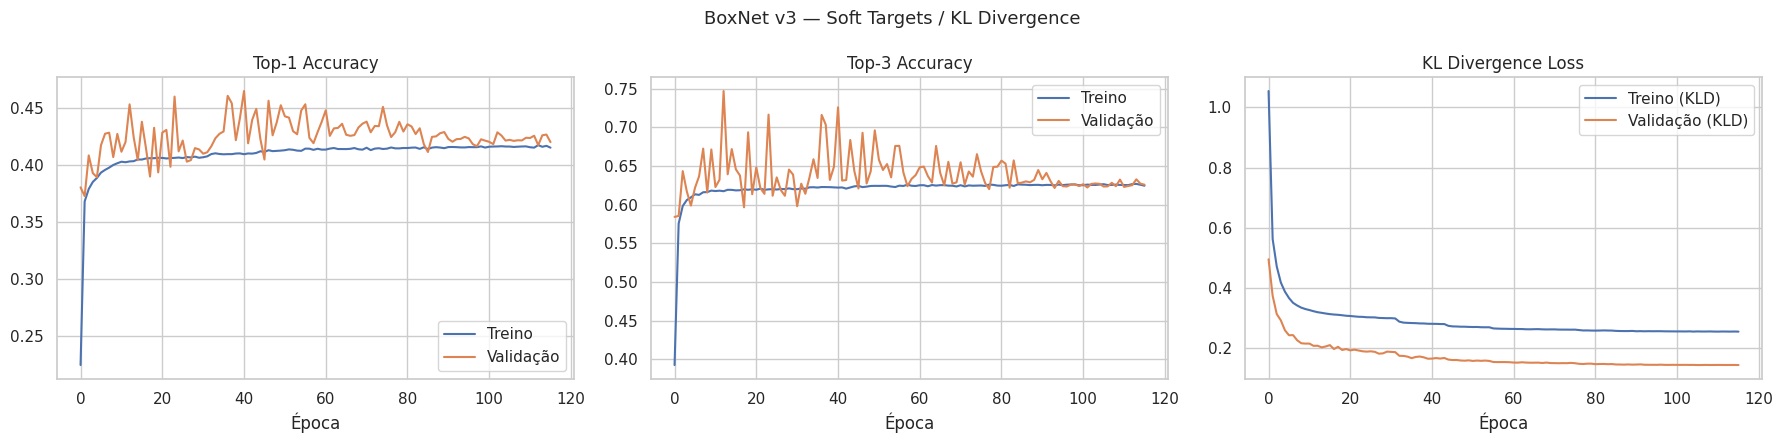


TOP-1 / TOP-3 ACCURACY POR FASE DO JOGO
  Fase                               N    Top-1    Top-3
  Abertura (0-9 tracos)          13890    8.0%   15.1%
  1ª Metade (10-17 tracos)       18696   40.9%   65.9%
  2ª Metade (18-25 tracos)       18641   67.8%   90.7%
  Final (21-31 tracos)            2323   63.8%   90.5%

  Optimal Move Accuracy (previsao in conjunto Minimax-otimo): 93.2%
  Media de jogadas Minimax-equivalentes por estado: 7.2



In [10]:
# =========================================================================
# 4. AVALIAÇÃO TEXTUAL — métricas para copiar/colar e comparar entre versões
#
# Com soft targets, y_train/val/test são distribuições de probabilidade.
# - model.evaluate retorna KLD (não cross-entropy) — magnitudes diferentes.
#   O que importa é a tendência (descendo) e o gap treino/val.
# - CategoricalAccuracy e TopKCategoricalAccuracy fazem argmax(y_true)
#   internamente, então top-1/top-3/top-5 continuam interpretáveis como
#   "o modelo escolheu a melhor jogada do Minimax no top-K?".
# =========================================================================

def avalia_conjunto(nome, X, y_soft):
    m = model.evaluate(X, y_soft, verbose=0, return_dict=True)
    return {
        'conjunto': nome,
        'amostras': X.shape[0],
        'kld_loss':  m['loss'],
        'top1_acc':  m['accuracy'],
        'top3_acc':  m['top3_acc'],
        'top5_acc':  m['top5_acc'],
    }

resultados = pd.DataFrame([
    avalia_conjunto('Treino',    X_train, y_train),
    avalia_conjunto('Validação', X_val,   y_val),
    avalia_conjunto('Teste',     X_test,  y_test),
])
print("=" * 70)
print("RESUMO DE DESEMPENHO (BoxNet v3 — soft targets / KL Divergence)")
print("=" * 70)
print(resultados.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

gap_top1 = resultados.loc[0, 'top1_acc'] - resultados.loc[1, 'top1_acc']
gap_kld  = resultados.loc[1, 'kld_loss'] - resultados.loc[0, 'kld_loss']
print(f"\nGap top1 (Treino - Val): {gap_top1*100:+.2f} pp   [< 5 pp saudável; > 10 pp = overfit]")
print(f"Gap KLD  (Val - Treino): {gap_kld:+.4f}")

ult = len(history.history['loss']) - 1
print(f"\nÚltima época: {ult+1}")
print(f"  kld_loss  treino={history.history['loss'][ult]:.4f}  val={history.history['val_loss'][ult]:.4f}")
print(f"  top1_acc  treino={history.history['accuracy'][ult]:.4f}  val={history.history['val_accuracy'][ult]:.4f}")

# =========================================================================
# Classification report — usa argmax do soft target como rótulo verdadeiro
# (argmax do Q-value = melhor jogada do Minimax, mesma semântica de antes)
# =========================================================================
y_pred_prob = model.predict(X_test, verbose=0)
y_pred_idx  = y_pred_prob.argmax(axis=1)

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT (conjunto de TESTE)")
print("=" * 70)
report = classification_report(
    y_test_idx, y_pred_idx,
    labels=list(range(num_classes)),
    target_names=[indice_para_rotulo[i] for i in range(num_classes)],
    digits=4, zero_division=0, output_dict=True,
)
print(f"  accuracy:      {report['accuracy']:.4f}")
print(f"  macro avg:     P={report['macro avg']['precision']:.4f}  "
      f"R={report['macro avg']['recall']:.4f}  F1={report['macro avg']['f1-score']:.4f}")
print(f"  weighted avg:  P={report['weighted avg']['precision']:.4f}  "
      f"R={report['weighted avg']['recall']:.4f}  F1={report['weighted avg']['f1-score']:.4f}")

por_classe = pd.DataFrame({
    rotulo: report[rotulo]
    for rotulo in [indice_para_rotulo[i] for i in range(num_classes)]
}).T
por_classe.index.name = 'jogada'
por_classe = por_classe.sort_values('f1-score', ascending=False)

print("\nTop 10 jogadas com melhor F1 (onde o modelo brilha):")
print(por_classe.head(10)[['precision', 'recall', 'f1-score', 'support']]
      .to_string(float_format=lambda v: f"{v:.4f}"))
print("\nBottom 5 jogadas (onde o modelo mais erra — verificar bordas):")
print(por_classe.tail(5)[['precision', 'recall', 'f1-score', 'support']]
      .to_string(float_format=lambda v: f"{v:.4f}"))

# =========================================================================
# Gráficos de treino
# =========================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

axes[0].plot(history.history['accuracy'],     label='Treino')
axes[0].plot(history.history['val_accuracy'], label='Validação')
axes[0].set_title('Top-1 Accuracy')
axes[0].set_xlabel('Época'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['top3_acc'],     label='Treino')
axes[1].plot(history.history['val_top3_acc'], label='Validação')
axes[1].set_title('Top-3 Accuracy')
axes[1].set_xlabel('Época'); axes[1].legend(); axes[1].grid(True)

axes[2].plot(history.history['loss'],     label='Treino (KLD)')
axes[2].plot(history.history['val_loss'], label='Validação (KLD)')
axes[2].set_title('KL Divergence Loss')
axes[2].set_xlabel('Época'); axes[2].legend(); axes[2].grid(True)

plt.suptitle('BoxNet v3 — Soft Targets / KL Divergence', fontsize=13)
plt.tight_layout(); plt.show()
# =========================================================================
# 5. METRICAS DIAGNOSTICAS EXTRAS
# =========================================================================

# 5.1  Top-1 / Top-3 por fase do jogo
# Conta tracados preenchidos nas posicoes H (r par, c impar) e V (r impar, c par)
mascara_tracos = np.zeros((9, 7), dtype=bool)
for _r in range(9):
    for _c in range(7):
        if (_r % 2 == 0 and _c % 2 == 1) or (_r % 2 == 1 and _c % 2 == 0):
            mascara_tracos[_r, _c] = True
tracos_jogados = (X_test[:, :, :, 0] != 0)[:, mascara_tracos].sum(axis=1)

fases = [
    (0,   9, 'Abertura (0-9 tracos)'),
    (10, 17, '1ª Metade (10-17 tracos)'),
    (18, 25, '2ª Metade (18-25 tracos)'),
    (26, 31, 'Final (21-31 tracos)'),
]
print('\n' + '=' * 70)
print('TOP-1 / TOP-3 ACCURACY POR FASE DO JOGO')
print('=' * 70)
print(f"  {'Fase':<28}  {'N':>6}  {'Top-1':>7}  {'Top-3':>7}")
for lo, hi, nome in fases:
    mask = (tracos_jogados >= lo) & (tracos_jogados <= hi)
    if mask.sum() == 0:
        continue
    t1 = (y_pred_idx[mask] == y_test_idx[mask]).mean()
    top3_pred = np.argsort(y_pred_prob[mask], axis=1)[:, -3:]
    t3 = (top3_pred == y_test_idx[mask, np.newaxis]).any(axis=1).mean()
    print(f"  {nome:<28}  {mask.sum():>6}  {t1:>6.1%}  {t3:>6.1%}")

# 5.2  Optimal Move Accuracy
# A previsao top-1 pertence ao conjunto de jogadas Minimax-otimas?
# S_test contem Q-values brutos; otimo = score == max_score (e slot disponivel)
max_scores_test = S_test.max(axis=1, keepdims=True)
eh_otimo       = (S_test == max_scores_test) & (S_test > -1e8)
pred_eh_otimo  = eh_otimo[np.arange(len(y_pred_idx)), y_pred_idx]
optimal_acc    = pred_eh_otimo.mean()
media_equiv    = eh_otimo.sum(axis=1).mean()
print(f'\n  Optimal Move Accuracy (previsao in conjunto Minimax-otimo): {optimal_acc:.1%}')
print(f'  Media de jogadas Minimax-equivalentes por estado: {media_equiv:.1f}')
print()


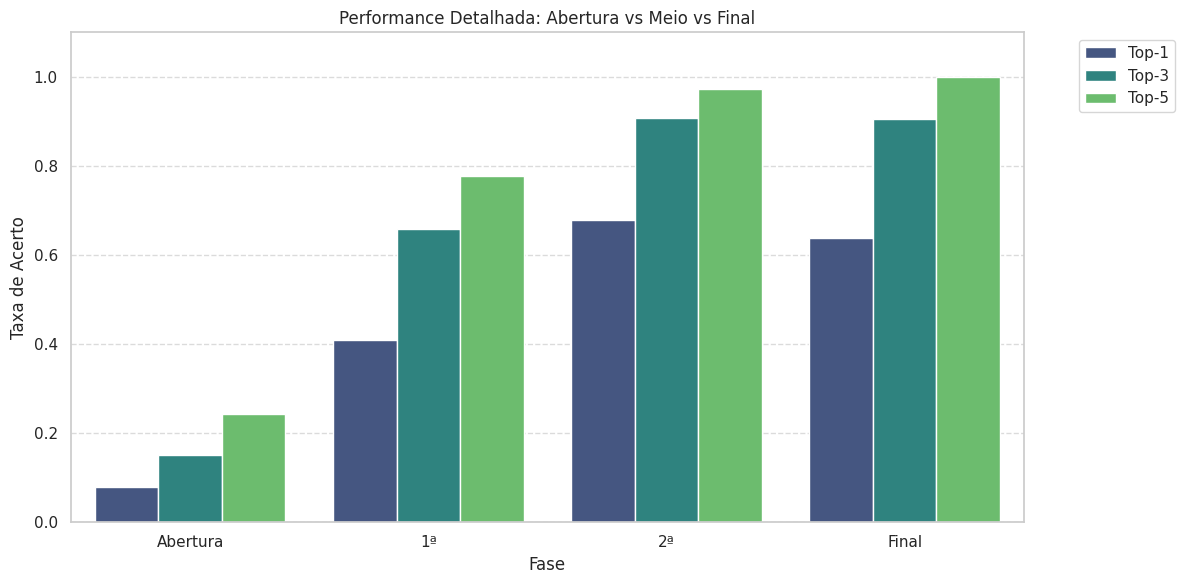

In [11]:
# =========================================================================
# 5.3 VISUALIZAÇÃO POR FASE (Gráfico Comparativo)
# =========================================================================
dados_fases = []
for lo, hi, nome in fases:
    mask = (tracos_jogados >= lo) & (tracos_jogados <= hi)
    if mask.sum() > 0:
        # Top-1
        t1 = (y_pred_idx[mask] == y_test_idx[mask]).mean()

        # Top-3 e Top-5
        argsorted_preds = np.argsort(y_pred_prob[mask], axis=1)
        top3_pred = argsorted_preds[:, -3:]
        top5_pred = argsorted_preds[:, -5:]

        t3 = (top3_pred == y_test_idx[mask, np.newaxis]).any(axis=1).mean()
        t5 = (top5_pred == y_test_idx[mask, np.newaxis]).any(axis=1).mean()

        fase_nome = nome.split(' ')[0]
        dados_fases.append({'Fase': fase_nome, 'Métrica': 'Top-1', 'Acurácia': t1})
        dados_fases.append({'Fase': fase_nome, 'Métrica': 'Top-3', 'Acurácia': t3})
        dados_fases.append({'Fase': fase_nome, 'Métrica': 'Top-5', 'Acurácia': t5})

df_fases = pd.DataFrame(dados_fases)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_fases, x='Fase', y='Acurácia', hue='Métrica', palette='viridis')
plt.title('Performance Detalhada: Abertura vs Meio vs Final')
plt.ylim(0, 1.1)
plt.ylabel('Taxa de Acerto')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


METRICAS POR GENERATION_MODE (Test Set)
Mode                      N   Top-1   Top-3   Top-5     OMA
------------------------------------------------------------------------
random(p=0)            7992   0.370   0.692   0.814   0.986
autoplay(p=1)         13166   0.474   0.617   0.705   0.916
autoplay(p=2)         29746   0.422   0.610   0.697   0.925
autoplay(p=3)          2646   0.422   0.611   0.697   0.923
------------------------------------------------------------------------
GLOBAL                53550   0.427   0.624   0.716   0.932


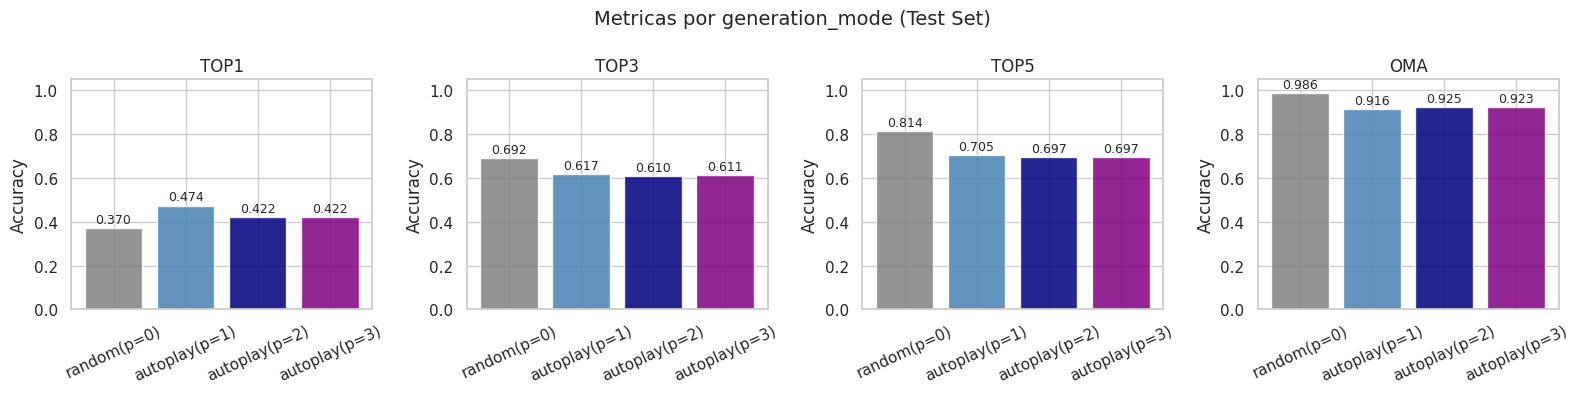

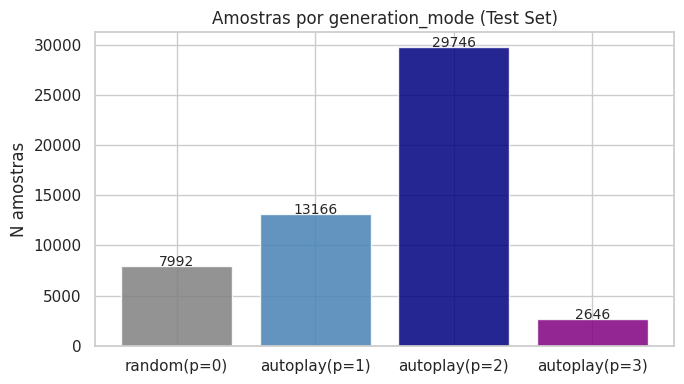

In [12]:
# =========================================================================
# METRICAS POR GENERATION_MODE
# Avalia Top-1, Top-3, Top-5 e OMA separadamente por modo de geracao.
# =========================================================================
y_pred_prob  = model.predict(X_test, verbose=0)
y_pred_idx   = y_pred_prob.argmax(axis=1)

# OMA: jogada predita esta no conjunto otimo do Minimax?
oma_flags = np.zeros(len(X_test), dtype=bool)
for i in range(len(X_test)):
    sv = scores_raw[idx_test[i]]
    valid = sv[sv > SCORE_IND]
    if len(valid) == 0: continue
    best_val = valid.max()
    pred_score = sv[y_pred_idx[i]]
    oma_flags[i] = (pred_score >= best_val - 1e-6)

def top_k_acc(pred_prob, true_idx, k):
    topk = np.argsort(pred_prob, axis=1)[:, -k:]
    return np.array([true_idx[i] in topk[i] for i in range(len(true_idx))]).mean()

modes_in_test = sorted(set(gen_test.tolist()))

print('\n' + '='*72)
print('METRICAS POR GENERATION_MODE (Test Set)')
print('='*72)
header = f'{"Mode":<20} {"N":>6} {"Top-1":>7} {"Top-3":>7} {"Top-5":>7} {"OMA":>7}'
print(header)
print('-'*72)

rows_data = []
for m in modes_in_test:
    mk = (gen_test == m)
    if mk.sum() == 0: continue
    t1 = (y_pred_idx[mk] == y_test_idx[mk]).mean()
    t3 = top_k_acc(y_pred_prob[mk], y_test_idx[mk], 3)
    t5 = top_k_acc(y_pred_prob[mk], y_test_idx[mk], 5)
    oma = oma_flags[mk].mean()
    n  = mk.sum()
    name = MODE_NAMES.get(m, str(m))
    print(f'{name:<20} {n:>6} {t1:>7.3f} {t3:>7.3f} {t5:>7.3f} {oma:>7.3f}')
    rows_data.append({'mode': name, 'n': n, 'top1': t1, 'top3': t3, 'top5': t5, 'oma': oma})

# Global
t1g = (y_pred_idx == y_test_idx).mean()
t3g = top_k_acc(y_pred_prob, y_test_idx, 3)
t5g = top_k_acc(y_pred_prob, y_test_idx, 5)
omag = oma_flags.mean()
print('-'*72)
print(f'{"GLOBAL":<20} {len(X_test):>6} {t1g:>7.3f} {t3g:>7.3f} {t5g:>7.3f} {omag:>7.3f}')

# ─── Grafico comparativo ───────────────────────────────────────────────────
if rows_data:
    df_m = pd.DataFrame(rows_data)
    metrics_cols = ['top1', 'top3', 'top5', 'oma']
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)
    colors = ['gray', 'steelblue', 'navy', 'purple']
    for ax, col in zip(axes, metrics_cols):
        bars = ax.bar(df_m['mode'], df_m[col],
                      color=[colors[int(m) % len(colors)] for m in modes_in_test],
                      alpha=0.85)
        ax.set_title(col.upper(), fontsize=12)
        ax.set_ylim(0, 1.05)
        ax.set_ylabel('Accuracy')
        ax.tick_params(axis='x', rotation=25)
        for bar, val in zip(bars, df_m[col]):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    plt.suptitle('Metricas por generation_mode (Test Set)', fontsize=14)
    plt.tight_layout(); plt.show()

# ─── Distribuicao das amostras de teste ────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
mode_labels = [MODE_NAMES.get(m, str(m)) for m in modes_in_test]
counts = [(gen_test == m).sum() for m in modes_in_test]
ax.bar(mode_labels, counts,
       color=[colors[int(m) % len(colors)] for m in modes_in_test], alpha=0.85)
ax.set_title('Amostras por generation_mode (Test Set)')
ax.set_ylabel('N amostras')
for i, v in enumerate(counts):
    ax.text(i, v + 5, str(v), ha='center', fontsize=10)
plt.tight_layout(); plt.show()


In [8]:
# =========================================================================
# EXPORTACAO PARA TENSORFLOW LITE
# =========================================================================
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

nome_arquivo = 'pontinhos_pequeno_profundidade_8.tflite'
with open(nome_arquivo, 'wb') as f:
    f.write(tflite_model)
print(f'Modelo salvo: {nome_arquivo} ({len(tflite_model)/1024:.1f} KB)')

from google.colab import files
files.download(nome_arquivo)


Saved artifact at '/tmp/tmpe73hhjpz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 9, 7, 1), dtype=tf.float32, name='tabuleiro_cru')
Output Type:
  TensorSpec(shape=(None, 31), dtype=tf.float32, name=None)
Captures:
  134269157315536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134269156710864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134269156711824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134269157311696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134269157316880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134269157315920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134269157313232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134269157314000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134269157317264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134269157316112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134269157317648:

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>